<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Heat%20Transfer/E_20_106_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***1. Cooling Load Calculation***

We calculate the total heat energy ($Q_{total}$) that must be removed to cool the milk and containers within 2 hours, in order to check the suitability of the unit.

---
*1.1 parameters*

| Description                         |    Notation   | Assigned Value         |
| :---------------------------------- | :-----------: | :--------------------- |
| Total number of containers          |      $n$      | 40                     |
| Combined mass of milk               |   $m_{milk}$  | $200\ \text{kg}$       |
| Combined mass of containers         |   $m_{cont}$  | $80\ \text{kg}$        |
| Specific heat capacity of milk      | $C_{p,;milk}$ | $4000\ \text{J/kg·K}$  |
| Specific heat capacity of aluminium | $C_{p,;cont}$ | $921.1\ \text{J/kg·K}$ |
| Overall temperature drop            |   $\Delta T$  | $22.5\ \text{K}$       |

---

*1.2 Energy Equations*

The total heat removed is calculated as the sum of the heat extracted from the milk and the containers:

$
Q_{\text{total}} = (m_m \, C_{p,m} \, \Delta T) + (m_c \, C_{p,c} \, \Delta T)
$

$
Q_{\text{milk}} = 200 \times 4000 \times 22.5 = 18{,}000{,}000 \ \text{J}
$

$
Q_{\text{cont}} = 80 \times 921.1 \times 22.5 = 1{,}657{,}980 \ \text{J}
$

$
Q_{\text{total}} = 19{,}657{,}980 \ \text{J} \approx \mathbf{19.66 \ \text{MJ}}
$


---

*1.3 Cooling Power Requirement*

To remove the calculated heat energy within a cooling duration of
$t = 7200 \ \text{s}$ (2 hours), the required cooling power is determined as:

$
\dot{Q}{\text{req}} = \dfrac{Q{\text{total}}}{t}
$

$
\dot{Q}_{\text{req}} = \dfrac{19{,}657{,}980}{7200}
$

$
\dot{Q}_{\text{req}} \approx 2730.28 \ \text{W} = 2.73 \ \text{kW}
$

Inference:
The cooling system must provide at least 2.73 kW of sensible cooling capacity, assuming no additional heat losses from the surroundings.

---

*1.4 Maximum Load Condition (Initial Temperature = 40°C)*

If the milk enters the system at a higher initial temperature of
$40^\circ\text{C}$, the corresponding temperature difference increases to:

$
\Delta T = 25 \ \text{K}
$

The total heat to be removed under this condition is calculated as:

$
Q = 40 \times \left[(5 \times 4000 + 2 \times 921.1) \times 25\right]
$

$
Q = 21{,}842{,}200 \ \text{J} \approx 21.84 \ \text{MJ}
$

The required cooling power for this worst-case condition becomes:

$
\dot{Q}_{\text{max}} = \dfrac{21{,}842{,}200}{7200}
$

$
\dot{Q}_{\text{max}} \approx 3.03 \ \text{kW}
$

In [ ]:
# --- Experimental Parameters & Physical Properties ---
num_containers = 40                 # total number of units
mass_container = 2.0                # container mass (kg)
mass_milk = 5.0                     # milk per container (kg)
cp_container = 921.1                # specific heat of aluminum (J/kg.K)
cp_milk = 4000.0                    # specific heat of milk (J/kg.K)
target_temp = 15.0                  # final storage temperature (°C)
cooling_time_hr = 2                 # cooling duration (hours)

# Convert cooling duration to seconds
cooling_time_sec = cooling_time_hr * 3600


def cooling_capacity_required(T_initial):
    """
    Returns the refrigeration capacity required (kW)
    to cool milk and containers to the target temperature.
    """
    temperature_drop = T_initial - target_temp

    # Heat removal from milk
    Q_milk = num_containers * mass_milk * cp_milk * temperature_drop

    # Heat removal from containers
    Q_container = num_containers * mass_container * cp_container * temperature_drop

    # Total heat removal (J)
    Q_total = Q_milk + Q_container

    # Convert energy to power (kW)
    capacity_kw = Q_total / cooling_time_sec / 1000
    return capacity_kw


# Operating temperature scenarios
T_avg = 37.5     # average incoming temperature (°C)
T_max = 40.0     # worst-case incoming temperature (°C)

capacity_avg = cooling_capacity_required(T_avg)
capacity_max = cooling_capacity_required(T_max)

print("=== Cooling Load Calculation ===")
print(f"Inlet Temperature: {T_avg}°C → Cooling Capacity: {capacity_avg:.3f} kW")
print(f"Inlet Temperature: {T_max}°C → Cooling Capacity: {capacity_max:.3f} kW")


=== Cooling Load Calculation ===
Inlet Temperature: 37.5°C → Cooling Capacity: 2.730 kW
Inlet Temperature: 40.0°C → Cooling Capacity: 3.034 kW



---

**2. Experimental Assessment of Cooling Performance**

This section describes the experimental procedure used to determine the **actual cooling capacity** ($\dot{Q}_{\text{act}}$) of the HVAC unit and to compare it with the **maximum required cooling load of 3.03 kW**.

---

*2.1 Test Arrangement and Measurement Method*

The airflow through the cooling duct is analyzed using a **duct traverse technique** to determine the thermodynamic properties of the air.

* **Duct geometry:** The cross-sectional area of the duct is calculated as
  $
  A = w \times h
  $

* **Air velocity:** Local air velocity ($v$) is measured at multiple locations across the duct cross-section using an anemometer, and the average velocity ($\bar{v}$) is obtained.

* **Air properties:** Dry-bulb temperature ($T_{db}$) and wet-bulb temperature ($T_{wb}$) are recorded at both the inlet (State 1) and outlet (State 2) of the cooling unit.

---

*2.2 Analytical Method*

The actual cooling capacity is calculated from the air mass flow rate and the change in specific enthalpy across the cooling coil.

I. Air Mass Flow Rate

$
\dot{m}_a = \rho , A , \bar{v}
$

where $\rho$ is the density of air (approximately $1.2 \ \text{kg/m}^3$).



II. Cooling Capacity Evaluation

The total heat removed from the air stream, including both sensible and latent components, is expressed as:

$
\dot{Q}_{\text{act}} = \dot{m}_a , \Delta h
$

$
\dot{Q}_{\text{act}} = \dot{m}_a , (h_1 - h_2)
$

The specific enthalpy values ($h_1$ and $h_2$) are obtained from psychrometric relationships using the measured dry-bulb and wet-bulb temperatures.

---

*2.3 Experimental Data Summary*

| Description                |             Notation            |   Unit  | Measured Value |
| :------------------------- | :-----------------------------: | :-----: | :------------- |
| **Duct Flow Area**         |               $A$               |  $m^2$  |                |
| **Average Air Velocity**   |            $\bar{v}$            |  $m/s$  |                |
| **Air Enthalpy at Inlet**  |              $h_1$              | $kJ/kg$ |                |
| **Air Enthalpy at Outlet** |              $h_2$              | $kJ/kg$ |                |
| **Actual Cooling Output**  | $\mathbf{\dot{Q}_{\text{act}}}$ |  **kW** |                |

---
*2.4 Cooling Performance Assessment*

The performance of the unit is evaluated by comparing the experimentally obtained cooling capacity with the required design load of
$3.03 \ \text{kW}$.

1. **Acceptable Performance:**
   $
   \dot{Q}_{\text{act}} \geq 3.03 \ \text{kW}
   $

2. **Borderline Performance:**
   $
   \dot{Q}_{\text{act}} < 3.03 \ \text{kW}
   $

---



**3. Experimental Evaluation of Evaporator Behavior**

---

*3.1 Measurement Locations and Variables*

The thermal performance of the evaporator is evaluated using temperature and velocity measurements taken at multiple locations along the air path:

* **Ambient Return Air ($T_1, T_2$):** Represents the surrounding air conditions entering the system.
* **Upstream of Evaporator ($T_3, T_4$):** Air state immediately before heat exchange occurs.
* **Downstream of Evaporator ($T_5, T_6$):** Condition of air after passing through the cooling coil.
* **Airflow Velocity ($V_{in}, V_{out}$):** Measured to estimate the air mass flow rate $\dot{m}_a$.

---

*3.2 Recorded Experimental Measurements*

| Fan Setting | $T_1$ | $T_2$ | $T_3$ | $T_4$ | $T_5$ | $T_6$ | $V_{in}$ | $V_{out}$ |
| :---------- | :---: | :---: | :---: | :---: | :---: | :---: | :------: | :-------: |
| **1**       |  29.5 |  25.2 |  29.1 |  21.2 |  26.4 |  19.9 |    0.0   |    0.0    |
| **2**       |  29.5 |  25.3 |  29.1 |  21.1 |  26.7 |  20.0 |    0.0   |    0.0    |
| **3**       |  29.9 |  25.3 |  29.5 |  21.5 |  24.3 |  19.7 |    0.6   |    0.5    |
| **4**       |  30.0 |  24.9 |  29.6 |  21.8 |  20.4 |  16.6 |    2.8   |    2.6    |
| **5**       |  29.2 |  23.7 |  29.3 |  21.2 |  20.8 |  16.2 |    5.6   |    5.4    |
| **6**       |  29.2 |  23.3 |  29.3 |  21.1 |  21.4 |  18.0 |    8.8   |    8.1    |
| **7**       |  29.4 |  23.3 |  29.3 |  21.1 |  21.5 |  18.2 |    9.3   |    8.9    |
| **8**       |  29.0 |  25.1 |  29.1 |  21.0 |  21.2 |  17.6 |    9.0   |    8.5    |
| **9**       |  28.7 |  22.9 |  28.9 |  20.9 |  21.3 |  17.4 |    9.8   |    8.7    |
| **10**      |  29.4 |  23.2 |  29.3 |  21.1 |  19.9 |  16.5 |    9.5   |    9.1    |

---

*3.3 Interpretation of Results*
Interpretation of Results and Performance Discussion

The effective cooling output of the system is evaluated by examining the air properties as it flows through the evaporator, transitioning from the inlet condition ($T_3, T_4$) to the outlet condition ($T_5, T_6$).

Evaporator Heat Transfer:
The primary cooling process takes place between the evaporator entrance and exit. The reduction in wet-bulb temperature from $T_4$ to $T_6$ reflects the total decrease in air enthalpy, accounting for both sensible temperature reduction and latent moisture removal.

Role of Air Mass Flow:
Increasing the fan speed raises the inlet air velocity ($V_{in}$), reaching a maximum value of $9.8 \ \text{m/s}$ at fan setting 9. This increase directly enhances the air mass flow rate ($\dot{m}_a$), which strongly influences the cooling capacity according to
$
\dot{Q} = \dot{m}_a , \Delta h
$.

Performance at Higher Fan Speeds:
At fan setting 10, the airflow velocity ($9.5 \ \text{m/s}$) is slightly lower than at setting 9; however, the lowest outlet dry-bulb temperature ($T_5 = 19.9^\circ\text{C}$) and wet-bulb temperature ($T_6 = 16.5^\circ\text{C}$) are observed. This suggests improved heat exchange effectiveness, likely due to enhanced interaction between the air stream and the evaporator surface.

System Suitability:
By computing the cooling capacity ($\dot{Q}$) at these higher fan settings using the enthalpy difference derived from $T_4$ and $T_6$, the system’s ability to meet or exceed the required 3.03 kW cooling demand for milk storage can be verified.


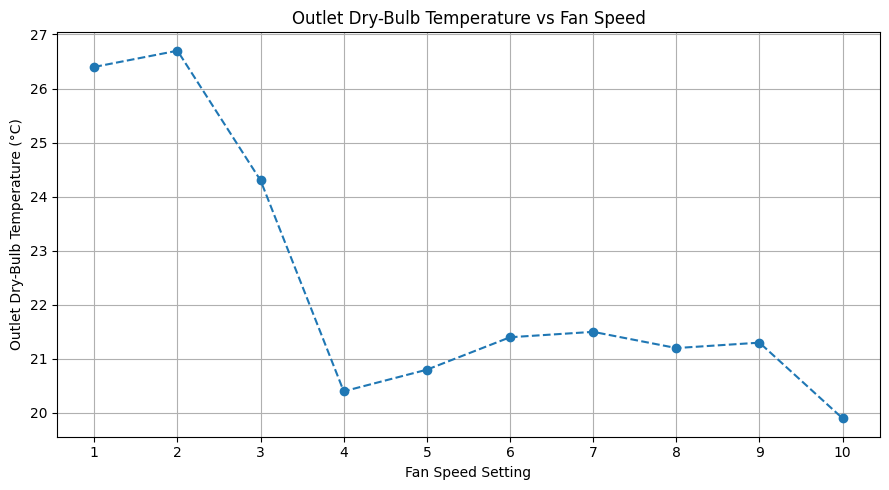

In [ ]:
import matplotlib.pyplot as plt

# --- Visualization: Outlet Temperature Variation with Fan Speed ---

# Fan speed levels and corresponding outlet dry-bulb temperatures
fan_speed = list(range(1, 11))
T5_outlet = [26.4, 26.7, 24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9]

# Create the figure
plt.figure(figsize=(9, 5))

# Plot temperature trend
plt.plot(fan_speed, T5_outlet, marker='o', linestyle='--')

# Graph labels and title
plt.title('Outlet Dry-Bulb Temperature vs Fan Speed')
plt.xlabel('Fan Speed Setting')
plt.ylabel('Outlet Dry-Bulb Temperature (°C)')

# Match x-axis ticks to discrete speed settings
plt.xticks(fan_speed)

# Grid for readability
plt.grid(True)

# Display plot
plt.tight_layout()
plt.show()



---

*3.4 Operational Viability Statement*

Considering the required cooling capacity of **3.03 kW**, the higher fan speed conditions will be further analyzed to determine whether the evaporator can satisfy the 2-hour cooling requirement for the **200 kg milk load**.

---


**4. Thermodynamic Analysis Methodology**

This section presents the analytical approach used to convert measured experimental data into the **actual cooling capacity** of the system, denoted as $\dot{Q}_{\text{act}}$.

---

*4.1 Air Mass Flow Rate Determination ($\dot{m}_a$)*

The rate of heat removal depends strongly on the mass flow rate of air passing through the evaporator. This parameter is calculated using the continuity relation based on the duct geometry and measured inlet velocity:

$
\dot{m}*a = \rho \cdot A \cdot V*{in}
$

where $\rho$ represents the density of air and $A$ is the cross-sectional area of the intake duct.

---

*4.2 Psychrometric Evaluation of Air Enthalpy ($h$)*

To properly capture both **sensible** and **latent** cooling effects, the specific enthalpy of moist air is calculated from dry-bulb and wet-bulb temperature measurements using standard psychrometric relationships.


I. Determination of Water Vapor Pressure

The saturation vapor pressure corresponding to the wet-bulb temperature is first estimated using the Magnus-type formulation:

$
P_{swb} = 0.61078 \cdot \exp!\left(\frac{17.27 \cdot T_{wb}}{T_{wb} + 237.3}\right)
$

The actual vapor pressure of the air is then obtained as:

$
P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db} - T_{wb})
$

II. Humidity Ratio and Specific Enthalpy

The humidity ratio, defined as the mass of water vapor per unit mass of dry air, is calculated as:

$
\omega = 0.62194 \cdot \frac{P_v}{P_{atm} - P_v}
$

Using this value, the specific enthalpy of moist air is determined by:

$
h = (c_{p,a} \cdot T_{db}) + \omega \cdot (h_{fg} + c_{p,v} \cdot T_{db})
$

**Constants used:**

$
c_{p,a} = 1.006 \ \text{kJ/kg·K}, \quad
h_{fg} = 2501 \ \text{kJ/kg}, \quad
c_{p,v} = 1.86 \ \text{kJ/kg·K}, \quad
P_{atm} = 101.325 \ \text{kPa}
$

---

*4.3 Evaluation of Actual Cooling Capacity ($\dot{Q}_{\text{act}}$)*

The cooling capacity delivered by the evaporator is obtained from the product of the air mass flow rate and the enthalpy difference between the inlet and outlet air streams:

$
\dot{Q}*{\text{act}} = \dot{m}*a \cdot (h*{\text{inlet}} - h*{\text{outlet}})
$

This formulation accounts for both temperature reduction and moisture removal effects.

---

*4.4 Performance Index*

To assess whether the system meets the design requirement, a **performance ratio** is defined as:

$
\eta = \frac{\dot{Q}*{\text{act}}}{\dot{Q}*{\text{req}}}
$

where the required cooling capacity is:

$
\dot{Q}_{\text{req}} = 3.03 \ \text{kW}
$

A value of $\eta \geq 1$ indicates that the system satisfies the cooling demand.

---




In [ ]:
import numpy as np
import pandas as pd

def moist_air_enthalpy(T_db, T_wb):
    """
    Computes the specific enthalpy of moist air (kJ/kg)
    using dry-bulb and wet-bulb temperatures.
    """
    P_atm = 101.325  # Atmospheric pressure in kPa

    # Step 1: Saturation vapor pressure at wet-bulb temperature
    P_s_wb = 0.61078 * np.exp((17.27 * T_wb) / (T_wb + 237.3))

    # Step 2: Actual vapor pressure of air
    P_v = P_s_wb - 0.000662 * P_atm * (T_db - T_wb)

    # Step 3: Humidity ratio (kg water vapor / kg dry air)
    omega = 0.62194 * (P_v / (P_atm - P_v))

    # Step 4: Specific enthalpy of moist air
    # cp_air = 1.006 kJ/kg.K, h_fg = 2501 kJ/kg, cp_vapor = 1.86 kJ/kg.K
    h = (1.006 * T_db) + omega * (2501 + 1.86 * T_db)

    return h


# Experimental measurements collected at different fan speeds
experiment_data = {
    'Speed': list(range(1, 11)),
    'T3_db': [29.1, 29.1, 29.5, 29.6, 29.3, 29.3, 29.3, 29.1, 28.9, 29.3],
    'T4_wb': [21.2, 21.1, 21.5, 21.8, 21.2, 21.1, 21.1, 21.0, 20.9, 21.1],
    'T5_db': [26.4, 26.7, 24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9],
    'T6_wb': [19.9, 20.0, 19.7, 16.6, 16.2, 18.0, 18.2, 17.6, 17.4, 16.5],
    'V_in':  [0.0, 0.0, 0.6, 2.8, 5.6, 8.8, 9.3, 9.0, 9.8, 9.5]
}

df = pd.DataFrame(experiment_data)

# Physical constants
air_density = 1.2   # kg/m^3
duct_area = 0.05    # m^2 (update with actual measured value)

# Enthalpy calculations at evaporator inlet and outlet
df['h_in'] = df.apply(lambda r: moist_air_enthalpy(r['T3_db'], r['T4_wb']), axis=1)
df['h_out'] = df.apply(lambda r: moist_air_enthalpy(r['T5_db'], r['T6_wb']), axis=1)

# Air mass flow rate calculation
df['m_dot'] = air_density * duct_area * df['V_in']

# Actual cooling capacity (kW)
df['Q_act_kW'] = df['m_dot'] * (df['h_in'] - df['h_out'])

# Check compliance with required cooling capacity
required_capacity = 3.03  # kW
df['Meets_Design_Load'] = df['Q_act_kW'] >= required_capacity

# Output results
print("=== Evaporator Cooling Capacity Evaluationڍ Analysis ===")
display(df[['Speed', 'V_in', 'h_in', 'h_out', 'Q_act_kW', 'Meets_Design_Load']])


=== Evaporator Cooling Capacity Evaluationڍ Analysis ===


,Speed,V_in,h_in,h_out,Q_act_kW,Meets_Design_Load
0,1,0.0,61.073062,56.668072,0.000000,False
1,2,0.0,60.712412,56.993035,0.000000,False
2,3,0.6,62.137676,56.114417,0.216837,False
3,4,2.8,63.235591,46.407566,2.827108,False
4,5,5.6,61.059983,45.190001,5.332314,True
5,6,8.8,60.699378,50.688121,5.285944,True
6,7,9.3,60.699378,51.321748,5.232718,True
7,8,9.0,60.353266,49.435954,5.895349,True
8,9,9.8,60.008556,48.805999,6.587104,True
9,10,9.5,60.699378,46.134187,8.302159,True


**6. Capacity Scaling Study: Expansion to 80 Containers**

This section evaluates the system modifications required to preserve the **2-hour cooling requirement** when the storage capacity is increased to **80 containers**.

---

*6.1 Updated Cooling Load Estimation*

When the number of containers is doubled, the total thermal energy that must be removed also increases proportionally, while the allowable cooling time remains unchanged at
$t = 7200 \ \text{s}$.

**Revised Total Heat Removal Requirement:**

$
Q_{\text{new}} = 2 \cdot Q_{\text{max}}
$

$
Q_{\text{new}} = 2 \cdot 21{,}842{,}200 \ \text{J}
$

$
Q_{\text{new}} = 43{,}684{,}400 \ \text{J} \approx \mathbf{43.68 \ \text{MJ}}
$

**Required Cooling Capacity for 80 Containers:**

$
\dot{Q}*{\text{req,80}} = \frac{Q*{\text{new}}}{7200}
$

$
\dot{Q}_{\text{req,80}} \approx \mathbf{6.06 \ \text{kW}}
$

This value represents the **minimum sensible and latent cooling demand**, excluding external heat gains.

---

*6.2 Equipment and System Enhancements*

I. Refrigeration Capacity Upgrade

The original system was designed around a maximum requirement of
$3.03 \ \text{kW}$. To reliably deliver **6.06 kW** under increased usage and account for real-world losses, a higher-capacity unit is necessary.

* **Compressor Selection:** Upgrade to a commercial unit rated at approximately
  **2.5 refrigeration tons** (≈ **8.5–9.0 kW**).
* **Design Margin:** The additional capacity provides tolerance for increased door openings, higher moisture load, and part-load inefficiencies.

II. Airflow Distribution Enhancement

With a larger number of containers, uniform air circulation becomes critical to avoid temperature gradients within the storage volume.

* **Airflow Requirement:**

$
\dot{m}*{a,\text{new}} \approx 2 \cdot \dot{m}*{a,\text{current}}
$

* **Engineering Solution:**
  Implement a **ducted plenum or manifold system** to distribute chilled air evenly across all container layers, minimizing stagnant regions and ensuring uniform cooling performance.

---
*6.3 Operational and Structural Considerations*

| Upgrade Area           | Recommended Action                                                                                                                                          |
| :--------------------- | :---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Thermal Insulation** | Replace existing walls with **100 mm polyurethane (PUR) insulated panels** to significantly reduce conductive heat gains.                                   |
| **Loading Strategy**   | If mechanical upgrades are limited, adopt **phased loading** (e.g., 40 containers every 2 hours) to maintain thermal stability and reduce peak load stress. |

---
